---
## Reorder Propensity (Logistic Regression)

**Business Question:** Among products a user has purchased before, which ones will they include in their next order?

**Approach — Prior → Train split (Kaggle-style):**
- **Feature history** — `order_products__prior.csv` (`op_pd`), already loaded. Contains every order-product row from a user's full prior purchase history.
- **Prediction target** — `order_products__train.csv` (`op_train_pd`). Each user has exactly one "train" order. Products present = **reordered (1)**, products previously bought but absent = **not reordered (0)**.

This mirrors the original Instacart Kaggle competition structure and avoids synthetic hold-out from the prior file.

**Algorithm:** Logistic Regression with features derived from prior purchase history:
- `purchase_count` — how many times the user bought this product (prior orders)
- `orders_since_last` — how many orders ago they last bought it
- `product_cycle` — average repurchase interval (days)
- `recency_decay` — exponential decay of last purchase
- `purchase_freq` — fraction of user's orders containing this product

In [ ]:
# ─── STEP 7: REORDER PROPENSITY — FEATURE ENGINEERING ─────────────────
# Goal: Build a predictive model that forecasts which products each
# customer will reorder in their next shopping trip.
# Business Value: Powers personalized "reorder" suggestions timed to
# each customer's buying cycle — increases conversion and basket size.

# --- Prior → Train split (Kaggle-style) ---
# History: all prior orders (op_pd) — what customers have bought in the past
# Target:  train orders (op_train_pd) — what customers actually bought next (our prediction target)

# Combine order details with product purchases to create a complete purchase history
history = op_pd[['order_id', 'product_id']].merge(
    orders_pd[['order_id', 'user_id', 'order_number', 'days_since_prior_order']],
    on='order_id', how='inner'
)

# Identify the customers who have a "train" order (i.e., a known next order to predict)
train_orders = orders_pd[orders_pd['eval_set'] == 'train'][['order_id', 'user_id']]
train_users = set(train_orders['user_id'].unique())
# Only keep history for customers we can validate predictions against
history = history[history['user_id'].isin(train_users)]

# Find each customer's most recent order number — this helps measure "recency"
user_max = history.groupby('user_id')['order_number'].max().reset_index(name='max_prior_order')

# ─── BUILD FEATURES FOR EACH CUSTOMER-PRODUCT PAIR ───────────────────
# For every (customer, product) combination, calculate behavioral signals
# that indicate how likely the customer is to reorder that product

up = (
    history.sort_values(['user_id', 'product_id', 'order_number'])
    .groupby(['user_id', 'product_id'])
    .agg(
        # How many times has this customer bought this specific product?
        purchase_count=('order_id', 'count'),
        # When did the customer last buy this product?
        last_order_num=('order_number', 'max'),
        # On average, how many days between this customer's orders?
        avg_days=('days_since_prior_order', 'mean'),
    )
    .reset_index()
)
up = up.merge(user_max, on='user_id')
# How many orders ago was the last purchase? Lower = more recent = more likely to reorder
up['orders_since_last'] = up['max_prior_order'] - up['last_order_num']

# Calculate the typical "repurchase cycle" for each product across all customers
# e.g., milk might be bought every 7 days, while olive oil every 30 days
prod_cycles = (
    history.sort_values(['user_id', 'product_id', 'order_number'])
    .pipe(lambda df: df[df.groupby(['user_id', 'product_id']).cumcount() >= 1])
    .groupby('product_id')['days_since_prior_order']
    .mean()
    .reset_index(name='product_cycle')
)
up = up.merge(prod_cycles, on='product_id', how='left')
# Default to 30-day cycle for products with no repeat purchase data
up['product_cycle'] = up['product_cycle'].fillna(30)

# Customer-level features: how experienced/diverse is this shopper?
user_f = history.groupby('user_id').agg(
    # How many total orders has this customer placed?
    user_total_orders=('order_number', 'nunique'),
    # How many different products has this customer tried?
    user_distinct_products=('product_id', 'nunique')
).reset_index()
up = up.merge(user_f, on='user_id', how='left')

# Product-level features: how popular is this product overall?
prod_f = history.groupby('product_id').agg(
    # Total number of times this product has been ordered (by anyone)
    product_popularity=('order_id', 'count'),
    # How many different customers have bought this product?
    product_buyers=('user_id', 'nunique')
).reset_index()
up = up.merge(prod_f, on='product_id', how='left')

# Ground truth: products in op_train_pd → reordered=1
# This is what the customer ACTUALLY bought next — our prediction target
target_label = op_train_pd[['order_id', 'product_id']].merge(
    train_orders, on='order_id', how='inner'
)[['user_id', 'product_id']].drop_duplicates()
target_label['reordered'] = 1

# Merge the target: 1 = customer DID reorder this product, 0 = they did NOT
up = up.merge(target_label, on=['user_id', 'product_id'], how='left')
up['reordered'] = up['reordered'].fillna(0).astype(int)

# ─── ENGINEERED FEATURES ─────────────────────────────────────────────
# Create additional "smart" features that capture business intuition

# Recency decay: the more orders since last purchase, the less likely to reorder
# Products bought recently have a score near 1.0; older purchases decay toward 0
up['recency_decay'] = np.exp(-up['orders_since_last'] / (up['purchase_count'] + 1))
# Purchase frequency: what fraction of the customer's trips included this product?
# A product bought in 80% of trips is practically a staple for that customer
up['purchase_freq'] = up['purchase_count'] / up['user_total_orders']
# Binary flag: was the product in one of the last 2 orders? (strong reorder signal)
up['is_recent'] = (up['orders_since_last'] <= 2).astype(int)
# Binary flag: has the product NOT been bought in 5+ orders? (may have abandoned it)
up['is_stale'] = (up['orders_since_last'] >= 5).astype(int)

# Final list of features the model will use to make predictions
feature_columns = [
    'purchase_count', 'orders_since_last', 'product_cycle', 'avg_days',
    'user_total_orders', 'user_distinct_products',
    'product_popularity', 'product_buyers',
    'recency_decay', 'purchase_freq', 'is_recent', 'is_stale',
]
features_df = up[feature_columns + ['user_id', 'product_id', 'reordered']].fillna(0)

print(f'Train users:    {len(train_users):>10,}')
print(f'Feature matrix: {len(features_df):>10,} samples × {len(feature_columns)} features')
print(f'Reorder rate:   {features_df["reordered"].mean():.1%} (natural class balance)')


Train users:        19,742
Feature matrix:  1,272,484 samples × 12 features
Reorder rate:   9.8% (natural class balance)


In [ ]:
# ─── TRAINING THE REORDER PREDICTION MODEL ────────────────────
# Train a Logistic Regression model that learns which customer-product
# behavior patterns predict a reorder. Then measure how accurate it is.

# Separate the features (inputs) from the target (what we're predicting)
X = features_df[feature_columns]
y = features_df['reordered']

# Split data: 80% for training, 20% for testing
# The model learns from training data and is evaluated on unseen test data
# "stratify" ensures the train/test split preserves the reorder ratio
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardize features so they're all on the same scale
# Without this, a feature with values 0-1000 would unfairly dominate one with values 0-1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the Logistic Regression model
# "balanced" class weights ensure the model doesn't just predict "won't reorder" for everything
# (since most customer-product pairs won't be reordered, the model could cheat by always saying "no")
lr_model = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs', random_state=42, class_weight='balanced')
lr_model.fit(X_train_scaled, y_train)

# Make predictions on the test set and evaluate accuracy
# The model outputs a probability (0 to 1) for each customer-product pair
y_pred_proba = lr_model.predict_proba(X_test_scaled)[:, 1]
# If probability ≥ 50%, we predict "will reorder"; otherwise "won't reorder"
y_pred = (y_pred_proba >= 0.5).astype(int)
# AUC-ROC measures how well the model distinguishes reorders from non-reorders
# 1.0 = perfect predictions, 0.5 = random guessing
auc_score = roc_auc_score(y_test, y_pred_proba)

# Feature importance: which behaviors matter most for predicting reorders?
# This tells us the KEY DRIVERS of customer repurchase decisions
fi = pd.DataFrame({'feature': feature_columns, 'importance': np.abs(lr_model.coef_[0])})
fi = fi.sort_values('importance', ascending=False)

print(f'AUC-ROC: {auc_score:.4f}')
print(f'\nClassification Report:\n{classification_report(y_test, y_pred)}')
print('Top Most Important Features:')
display(fi)


AUC-ROC: 0.8157

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.74      0.84    229565
           1       0.24      0.74      0.36     24932

    accuracy                           0.74    254497
   macro avg       0.60      0.74      0.60    254497
weighted avg       0.89      0.74      0.79    254497

Top Most Important Features:


,feature,importance
8,recency_decay,0.584406
1,orders_since_last,0.529974
9,purchase_freq,0.387208
7,product_buyers,0.176222
0,purchase_count,0.157198
10,is_recent,0.060204
2,product_cycle,0.058714
4,user_total_orders,0.047679
11,is_stale,0.035143
5,user_distinct_products,0.031137


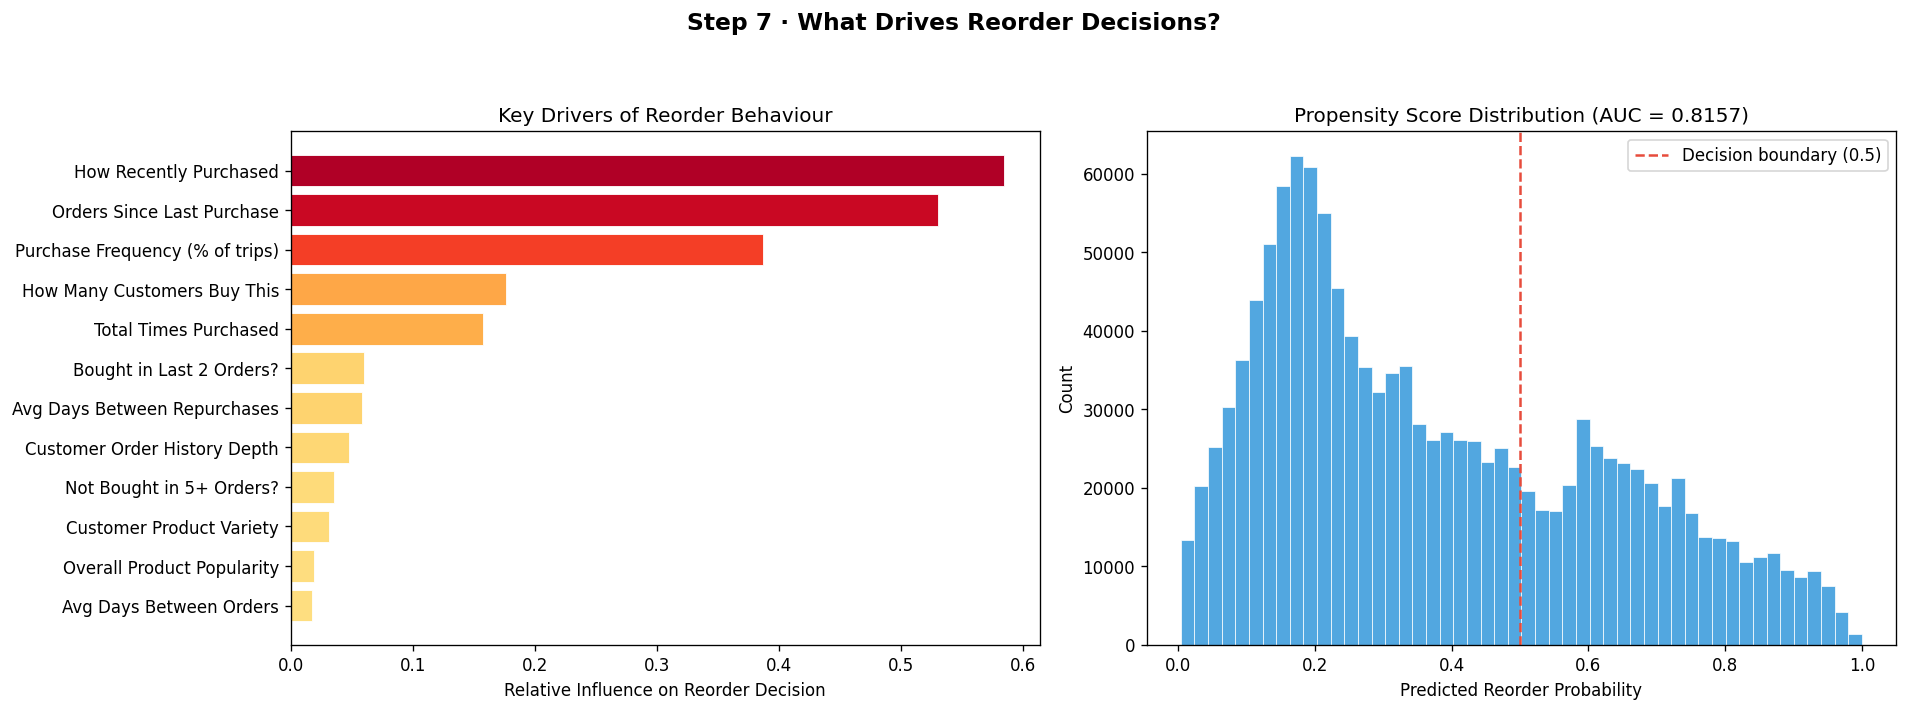

In [ ]:
# ─── STEP 7 VISUALIZATION: WHAT DRIVES REORDER DECISIONS ──────────────
# Two charts: (1) Which factors matter most for reorders (business language),
# (2) Distribution of reorder probability scores across all customer-product pairs

# Translate technical feature names into business-friendly labels
BUSINESS_LABELS = {
    'recency_decay':          'How Recently Purchased',
    'orders_since_last':      'Orders Since Last Purchase',
    'purchase_freq':          'Purchase Frequency (% of trips)',
    'purchase_count':         'Total Times Purchased',
    'product_cycle':          'Avg Days Between Repurchases',
    'avg_days':               'Avg Days Between Orders',
    'user_total_orders':      'Customer Order History Depth',
    'user_distinct_products': 'Customer Product Variety',
    'product_popularity':     'Overall Product Popularity',
    'product_buyers':         'How Many Customers Buy This',
    'is_recent':              'Bought in Last 2 Orders?',
    'is_stale':               'Not Bought in 5+ Orders?',
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Step 7 · What Drives Reorder Decisions?', fontsize=14, fontweight='bold')

# LEFT CHART: Feature importance — which behavioral signals predict reorders best?
# The longest bars are the factors marketing and product teams should focus on
fi_sorted = fi.sort_values('importance')
fi_sorted['label'] = fi_sorted['feature'].map(BUSINESS_LABELS).fillna(fi_sorted['feature'])
cmap_fi = plt.cm.YlOrRd
norm_fi = fi_sorted['importance'] / fi_sorted['importance'].max()
fi_colors = [cmap_fi(0.2 + 0.7 * v) for v in norm_fi.values]
axes[0].barh(fi_sorted['label'], fi_sorted['importance'], color=fi_colors, edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('Relative Influence on Reorder Decision')
axes[0].set_title('Key Drivers of Reorder Behaviour')

# RIGHT CHART: Histogram of predicted reorder probabilities
# Most scores cluster near 0 (unlikely to reorder) — the red line at 0.5 is the decision boundary
scores_all = lr_model.predict_proba(scaler.transform(X))[:, 1]
axes[1].hist(scores_all, bins=50, color='#3498db', edgecolor='white', linewidth=0.5, alpha=0.85)
axes[1].set_xlabel('Predicted Reorder Probability')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Propensity Score Distribution (AUC = {auc_score:.4f})')
axes[1].axvline(0.5, color='#e74c3c', ls='--', lw=1.5, label='Decision boundary (0.5)')
axes[1].legend()

fig.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


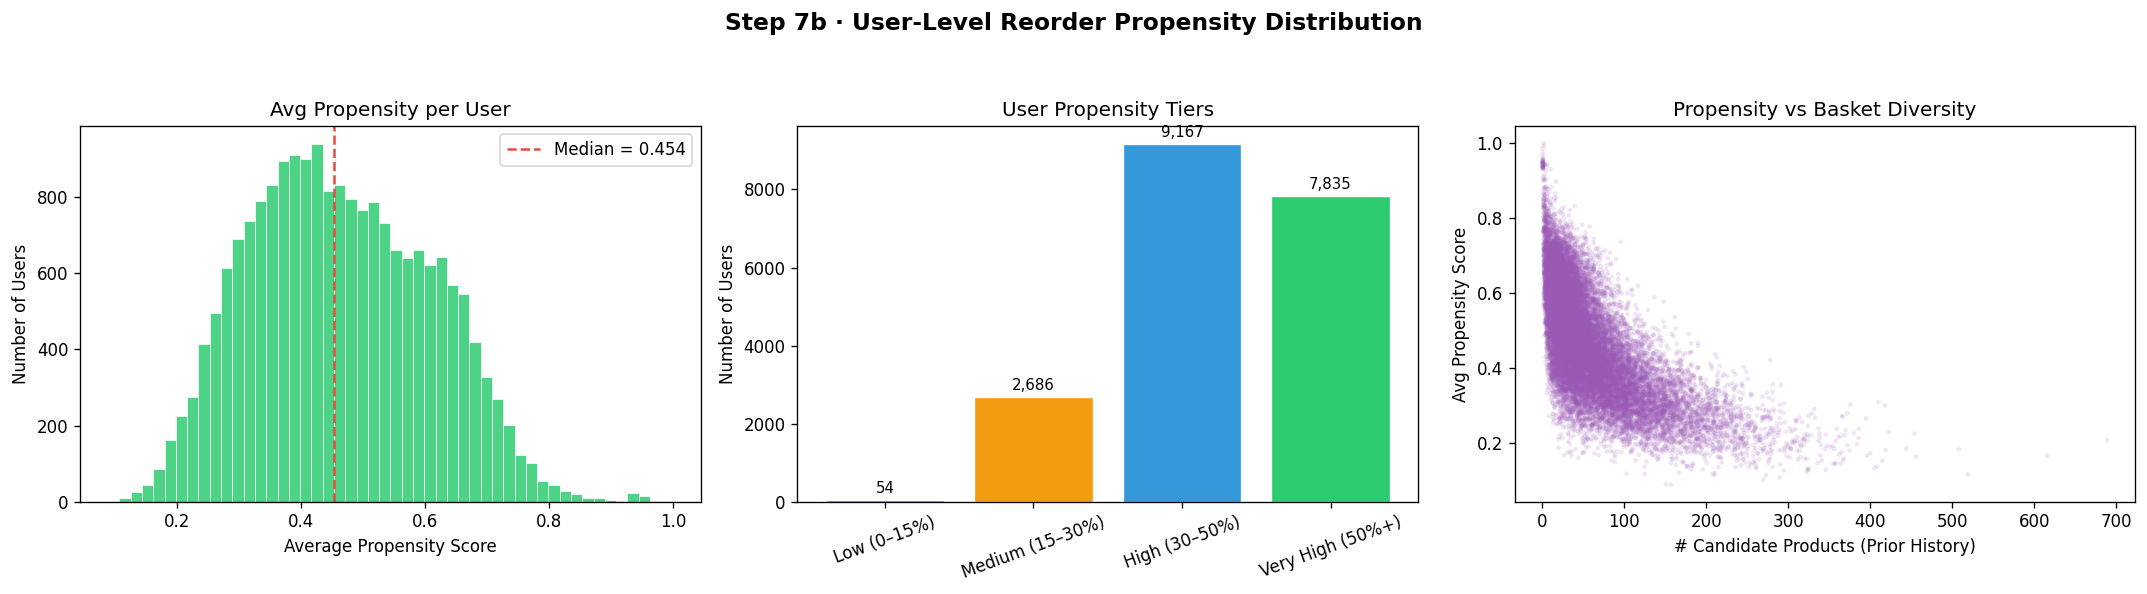


User-Level Summary:
  Total users:           19,742
  Median propensity:      0.454
  Mean propensity:        0.464

Tier Breakdown:
  Low (0–15%)                54 users (0.3%)
  Medium (15–30%)         2,686 users (13.6%)
  High (30–50%)           9,167 users (46.4%)
  Very High (50%+)        7,835 users (39.7%)


In [ ]:
# ─── USER-LEVEL REORDER PROPENSITY ──────────────────────────
# Aggregate product-level predictions up to the customer level
# This shows which customers are most likely to place a repeat order overall

# Calculate each customer's average, max, and candidate count for reorder scores
user_propensity = features_df[['user_id']].copy()
user_propensity['score'] = lr_model.predict_proba(scaler.transform(X))[:, 1]

user_agg = user_propensity.groupby('user_id')['score'].agg(
    avg_propensity='mean', max_propensity='max', n_candidates='count'
).reset_index()

# Tier customers by their average propensity to reorder
# This helps CRM teams prioritize outreach — "Very High" customers are loyal but may just
# need a reminder, while "Low" customers may need incentives to return
user_agg['tier'] = pd.cut(
    user_agg['avg_propensity'],
    bins=[0, 0.15, 0.30, 0.50, 1.0],
    labels=['Low (0–15%)', 'Medium (15–30%)', 'High (30–50%)', 'Very High (50%+)']
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Step 7b · User-Level Reorder Propensity Distribution', fontsize=14, fontweight='bold')

# LEFT CHART: Distribution of average propensity scores across all customers
axes[0].hist(user_agg['avg_propensity'], bins=50, color='#2ecc71', edgecolor='white', linewidth=0.5, alpha=0.85)
axes[0].set_xlabel('Average Propensity Score')
axes[0].set_ylabel('Number of Users')
axes[0].set_title('Avg Propensity per User')
axes[0].axvline(user_agg['avg_propensity'].median(), color='#e74c3c', ls='--', lw=1.5,
                label=f'Median = {user_agg["avg_propensity"].median():.3f}')
axes[0].legend()

# MIDDLE CHART: How many customers fall into each propensity tier?
# This is the targeting breakdown for email campaigns and push notifications
tier_counts = user_agg['tier'].value_counts().reindex(
    ['Low (0–15%)', 'Medium (15–30%)', 'High (30–50%)', 'Very High (50%+)']
)
tier_colors = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71']
bars = axes[1].bar(tier_counts.index, tier_counts.values, color=tier_colors, edgecolor='white', linewidth=0.8)
axes[1].set_ylabel('Number of Users')
axes[1].set_title('User Propensity Tiers')
axes[1].tick_params(axis='x', rotation=20)
for bar, val in zip(bars, tier_counts.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + tier_counts.max() * 0.01,
                 f'{val:,}', ha='center', va='bottom', fontsize=9)

# RIGHT CHART: Scatter plot — do customers who buy more diverse products have lower reorder rates?
# Each dot is a customer; this reveals the relationship between variety-seeking and loyalty
axes[2].scatter(user_agg['n_candidates'], user_agg['avg_propensity'],
                alpha=0.15, s=8, color='#9b59b6', edgecolors='none')
axes[2].set_xlabel('# Candidate Products (Prior History)')
axes[2].set_ylabel('Avg Propensity Score')
axes[2].set_title('Propensity vs Basket Diversity')

fig.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

# Print a summary table with counts and percentages for each tier
print(f'\nUser-Level Summary:')
print(f'  Total users:       {len(user_agg):>10,}')
print(f'  Median propensity: {user_agg["avg_propensity"].median():>10.3f}')
print(f'  Mean propensity:   {user_agg["avg_propensity"].mean():>10.3f}')
print(f'\nTier Breakdown:')
for tier, count in tier_counts.items():
    pct = count / len(user_agg) * 100
    print(f'  {tier:<20s} {count:>8,} users ({pct:.1f}%)')
